# RNN — PyTorch Pipeline

## Model: Recurrent Neural Network (Vanilla RNN + GRU)
- **Dataset**: ECG5000 — 4,000 train / 1,000 test, 140 timesteps, 5 heartbeat classes
- **Task**: Classify heartbeat arrhythmias (severe class imbalance: 121.6x ratio)
- **Framework showcase**: Vanishing gradient demonstration + GRU as the fix + architecture sweep

## Evaluation Strategy
- **Primary metric**: Macro F1 (not accuracy — 58% majority class makes accuracy misleading)
- **Training curves**: Loss + accuracy + macro F1 (train/val)
- **Gradient analysis**: Per-layer gradient norms comparing vanilla RNN vs GRU

## Pipeline
1. Load data + config
2. Vanilla RNN baseline
3. Vanishing gradient demonstration
4. GRU model (gated fix)
5. Architecture sweep (hidden size, depth, bidirectional)
6. Best model — full evaluation
7. Training visualization
8. Performance benchmarks
9. Save results

In [1]:
# Step 1: Setup
"""
Imports, config, load preprocessed ECG5000, class weights to GPU
Input shape: (batch, 140, 1) — sequence of 140 timesteps, 1 feature
Class weights from preprocessing metadata (121.6x imbalance)
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import sys
import os
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier, macro_f1_score
from utils.rnn_utils import compute_gradient_norms
from utils.visualization import (plot_training_history, plot_confusion_matrix_multiclass,
                                  plot_gradient_flow, plot_ecg_predictions,
                                  plot_hidden_state_evolution)
from utils.performance import track_performance, get_model_size, track_inference
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "PyTorch"
MODEL_NAME = "RNN"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 64
N_CLASSES = 5
SEQ_LEN = 140
N_FEATURES = 1
CLASS_NAMES = ['Normal', 'R-on-T PVC', 'PVC', 'SP', 'UB']

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_STATE)

# Load data
X_train, X_test, y_train, y_test, metadata = load_processed_data('rnn')

# Class weights from preprocessing (inverse frequency for 121.6x imbalance)
class_weights = metadata['class_weights']
class_weights_tensor = torch.tensor(
    [class_weights[str(i)] for i in range(N_CLASSES)],
    dtype=torch.float32
).to(device)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

print("=" * 60)
print(f"[1/9] {FRAMEWORK} — {MODEL_NAME} Pipeline")
print("=" * 60)
print(f"Device: {device} ({torch.cuda.get_device_name() if torch.cuda.is_available() else 'CPU'})")
print(f"Train: {X_train_t.shape} | Test: {X_test_t.shape}")
print(f"Sequence: {SEQ_LEN} timesteps x {N_FEATURES} feature")
print(f"Classes: {N_CLASSES} ({', '.join(CLASS_NAMES)})")
print(f"Batch size: {BATCH_SIZE} ({len(train_loader)} batches/epoch)")
print(f"Class imbalance: {max(class_weights.values()) / min(class_weights.values()):.1f}x")
print(f"Class weights: {[f'{class_weights[str(i)]:.2f}' for i in range(N_CLASSES)]}")

[1/9] PyTorch — RNN Pipeline
Device: cuda (NVIDIA GeForce RTX 4090)
Train: torch.Size([4000, 140, 1]) | Test: torch.Size([1000, 140, 1])
Sequence: 140 timesteps x 1 feature
Classes: 5 (Normal, R-on-T PVC, PVC, SP, UB)
Batch size: 64 (63 batches/epoch)
Class imbalance: 122.9x
Class weights: ['0.34', '0.57', '10.39', '5.16', '42.11']


In [2]:
# Step 2: Vanilla RNN Baseline
"""
nn.RNN with tanh activation — the simplest recurrent architecture
Uses last hidden state (timestep 140) for classification
Expect: decent accuracy but poor macro F1 on minority classes
Vanilla RNN suffers from vanishing gradients — proven in Cell 3
"""

print("=" * 60)
print("[2/9] Vanilla RNN — Baseline")
print("=" * 60)


class VanillaRNN(nn.Module):
    """
    Simple RNN for sequence classification.

    Args:
        input_size: Features per timestep (1 for univariate ECG)
        hidden_size: RNN hidden dimension
        num_layers: Stacked RNN layers
        n_classes: Output classes
    """
    def __init__(self, input_size, hidden_size, num_layers, n_classes):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                           batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        # x: (batch, seq_len, features)
        output, h_n = self.rnn(x)
        # Use last timestep output for classification
        last_hidden = output[:, -1, :]
        return self.fc(last_hidden)


def train_rnn(model, train_loader, criterion, max_epochs=50, patience=10, lr=1e-3):
    # Train RNN with early stopping on validation macro F1
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train/val split from loaded tensors
    n_val = int(len(X_train_t) * 0.1)
    perm = torch.randperm(len(X_train_t), device=device,
                           generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
    val_idx, tr_idx = perm[:n_val], perm[n_val:]

    X_val = X_train_t[val_idx]
    y_val = y_train_t[val_idx]

    tr_ds = TensorDataset(X_train_t[tr_idx], y_train_t[tr_idx])
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    best_val_f1 = 0.0
    wait = 0
    best_state = None
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        for batch_x, batch_y in tr_loader:
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_y)
            correct += (logits.argmax(1) == batch_y).sum().item()
            total += len(batch_y)

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)

        # Validate
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val).item()
            val_preds = val_logits.argmax(1).cpu().numpy()
            val_acc = float((val_preds == y_val.cpu().numpy()).mean())
            val_f1 = float(macro_f1_score(y_val.cpu().numpy(), val_preds))

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            wait = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)

    return {
        'train_loss': train_losses, 'val_loss': val_losses,
        'train_acc': train_accs, 'val_acc': val_accs,
        'epochs': len(train_losses), 'best_val_f1': best_val_f1
    }


# Build and train vanilla RNN
vanilla_rnn = VanillaRNN(N_FEATURES, hidden_size=64, num_layers=2,
                          n_classes=N_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

n_params_vanilla = sum(p.numel() for p in vanilla_rnn.parameters())
print(f"Architecture: RNN(1, 64, 2 layers) -> FC(64, 5)")
print(f"Parameters: {n_params_vanilla:,}")

with track_performance(gpu=True) as perf_vanilla:
    hist_vanilla = train_rnn(vanilla_rnn, train_loader, criterion,
                              max_epochs=50, patience=10)
    torch.cuda.synchronize()

# Evaluate on test
vanilla_rnn.eval()
with torch.no_grad():
    test_logits = vanilla_rnn(X_test_t)
    vanilla_preds = test_logits.argmax(1).cpu().numpy()

vanilla_metrics = evaluate_classifier(y_test, vanilla_preds)
vanilla_f1, vanilla_per_class = macro_f1_score(y_test, vanilla_preds, return_per_class=True)

print(f"\nEpochs: {hist_vanilla['epochs']} | Best val F1: {hist_vanilla['best_val_f1']:.4f}")
print(f"Training time: {perf_vanilla['time']:.2f}s")
print(f"\nTest Results:")
print(f"  Accuracy:  {vanilla_metrics['accuracy']:.4f}")
print(f"  Macro F1:  {vanilla_f1:.4f}")
print(f"\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, vanilla_per_class)):
    print(f"  {name:<15} F1={f1:.4f} (n={np.sum(y_test == i)})")


[2/9] Vanilla RNN — Baseline
Architecture: RNN(1, 64, 2 layers) -> FC(64, 5)
Parameters: 12,933

Epochs: 28 | Best val F1: 0.5368
Training time: 8.01s

Test Results:
  Accuracy:  0.8460
  Macro F1:  0.4938

Per-class F1:
  Normal          F1=0.9539 (n=584)
  R-on-T PVC      F1=0.8637 (n=353)
  PVC             F1=0.2917 (n=19)
  SP              F1=0.3235 (n=39)
  UB              F1=0.0364 (n=5)


[3/9] Vanishing Gradient Demonstration
Vanilla RNN — Gradient Norms (L2):
---------------------------------------------
  rnn.weight_ih_l0                    4.370973e-01
  rnn.weight_hh_l0                    1.577275e+00
  rnn.bias_ih_l0                      3.204504e-01
  rnn.bias_hh_l0                      3.204504e-01
  rnn.weight_ih_l1                    4.497405e-01
  rnn.weight_hh_l1                    9.578745e-01
  rnn.bias_ih_l1                      1.133305e-01
  rnn.bias_hh_l1                      1.133305e-01
  fc.weight                           1.845902e+00
  fc.bias                             2.615404e-01

Gradient range: 4.37e-01 → 1.85e+00
Max/min ratio: 4.2x


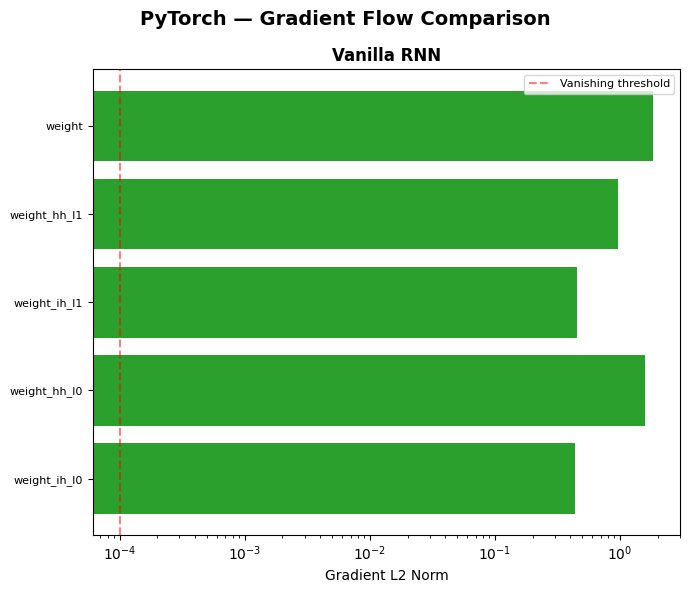

In [3]:
# Step 3: Vanishing Gradient Demonstration
"""
THE key pedagogical cell — proves WHY gated architectures exist.
compute_gradient_norms() does a forward+backward pass on a small batch,
then measures L2 norm of gradients at each layer.

Vanilla RNN: gradients shrink exponentially through layers (vanishing)
GRU (trained next cell): reset/update gates preserve gradient flow
"""

print("=" * 60)
print("[3/9] Vanishing Gradient Demonstration")
print("=" * 60)

# Use a small batch for gradient computation
grad_batch_x = X_train_t[:64]
grad_batch_y = y_train_t[:64]

# Compute gradient norms for vanilla RNN
vanilla_grads = compute_gradient_norms(
    vanilla_rnn, criterion, grad_batch_x, grad_batch_y, framework='pytorch'
)

print("Vanilla RNN — Gradient Norms (L2):")
print("-" * 45)
for name, norm in vanilla_grads.items():
    tag = " ← VANISHING" if norm < 1e-4 else ""
    print(f"  {name:<35} {norm:.6e}{tag}")

# Summary stats
weight_grads = {k: v for k, v in vanilla_grads.items() if 'weight' in k}
min_grad = min(weight_grads.values())
max_grad = max(weight_grads.values())
ratio = max_grad / min_grad if min_grad > 0 else float('inf')

print(f"\nGradient range: {min_grad:.2e} → {max_grad:.2e}")
print(f"Max/min ratio: {ratio:.1f}x")
if ratio > 100:
    print("  Large gradient ratio confirms vanishing gradient problem")
    print("  Early layers receive ~0 gradient → can't learn long-range patterns")
    print("  This is why GRU/LSTM gates were invented")

# Plot — just vanilla RNN for now (GRU added after Cell 4)
plot_gradient_flow({'Vanilla RNN': vanilla_grads}, framework='PyTorch',
                   save_path='results/gradient_flow_vanilla.png')

[4/9] GRU Model
Architecture: GRU(1, 64, 2 layers) -> FC(64, 5)
Parameters: 38,149 (vs vanilla RNN: 12,933)
  GRU has ~3x params due to 3 gate matrices per layer

Epochs: 17 | Best val F1: 0.5369
Training time: 2.85s

Test Results:
  Accuracy:  0.8680
  Macro F1:  0.4963

Per-class F1:
  Normal          F1=0.9494 (n=584)
  R-on-T PVC      F1=0.8991 (n=353)
  PVC             F1=0.3019 (n=19)
  SP              F1=0.2824 (n=39)
  UB              F1=0.0488 (n=5)

Gradient Comparison: Vanilla RNN vs GRU
Vanilla RNN — gradient ratio: 4.2x  (range: 4.37e-01 → 1.85e+00)
GRU         — gradient ratio: 4.1x  (range: 3.72e-01 → 1.52e+00)


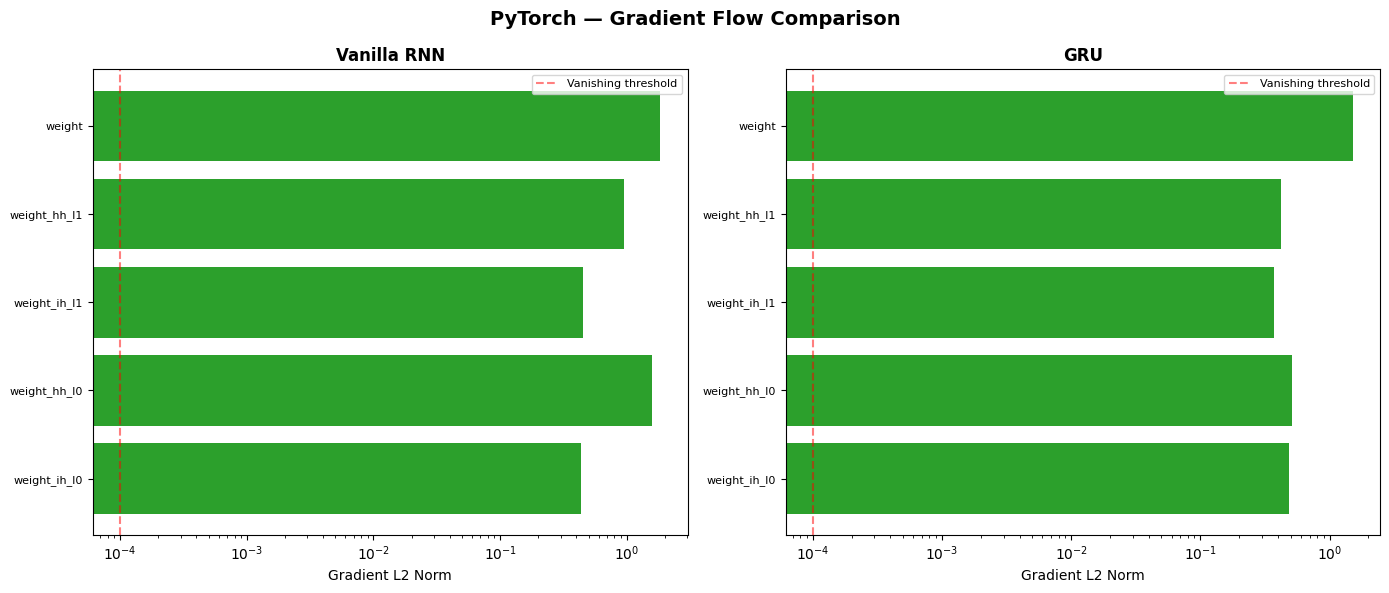


Vanilla RNN vs GRU — Performance Comparison
Metric                Vanilla RNN          GRU      Delta
------------------------------------------------------
Accuracy                   0.8460       0.8680    +0.0220
Macro F1                   0.4938       0.4963    +0.0025
Parameters                 12,933       38,149
Training time (s)            8.01         2.85

Per-class F1 comparison:
  Normal          0.9539 → 0.9494  (-0.0045)
  R-on-T PVC      0.8637 → 0.8991  (+0.0354)
  PVC             0.2917 → 0.3019  (+0.0102)
  SP              0.3235 → 0.2824  (-0.0412)
  UB              0.0364 → 0.0488  (+0.0124)


In [4]:
# Step 4: GRU Model
"""
GRU (Gated Recurrent Unit) — adds reset/update gates to control information flow.
Same architecture (64 hidden, 2 layers) for fair comparison vs vanilla RNN.
Gates allow selective memory: update gate decides what to keep, reset gate
decides what to forget. This should improve minority class recognition.
"""

print("=" * 60)
print("[4/9] GRU Model")
print("=" * 60)


class GRUClassifier(nn.Module):
    """
    GRU for sequence classification.

    Args:
        input_size: Features per timestep (1 for univariate ECG).
        hidden_size: GRU hidden dimension.
        num_layers: Stacked GRU layers.
        n_classes: Output classes.
    """
    def __init__(self, input_size, hidden_size, num_layers, n_classes):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                           batch_first=True)
        self.fc = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        output, h_n = self.gru(x)
        last_hidden = output[:, -1, :]
        return self.fc(last_hidden)


# Build and train GRU — same config as vanilla RNN for fair comparison
gru_model = GRUClassifier(N_FEATURES, hidden_size=64, num_layers=2,
                            n_classes=N_CLASSES).to(device)
criterion_gru = nn.CrossEntropyLoss(weight=class_weights_tensor)

n_params_gru = sum(p.numel() for p in gru_model.parameters())
print(f"Architecture: GRU(1, 64, 2 layers) -> FC(64, 5)")
print(f"Parameters: {n_params_gru:,} (vs vanilla RNN: {n_params_vanilla:,})")
print(f"  GRU has ~3x params due to 3 gate matrices per layer")

with track_performance(gpu=True) as perf_gru:
    hist_gru = train_rnn(gru_model, train_loader, criterion_gru,
                          max_epochs=50, patience=10)
    torch.cuda.synchronize()

# Evaluate on test
gru_model.eval()
with torch.no_grad():
    test_logits_gru = gru_model(X_test_t)
    gru_preds = test_logits_gru.argmax(1).cpu().numpy()

gru_metrics = evaluate_classifier(y_test, gru_preds)
gru_f1, gru_per_class = macro_f1_score(y_test, gru_preds, return_per_class=True)

print(f"\nEpochs: {hist_gru['epochs']} | Best val F1: {hist_gru['best_val_f1']:.4f}")
print(f"Training time: {perf_gru['time']:.2f}s")
print(f"\nTest Results:")
print(f"  Accuracy:  {gru_metrics['accuracy']:.4f}")
print(f"  Macro F1:  {gru_f1:.4f}")
print(f"\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, gru_per_class)):
    print(f"  {name:<15} F1={f1:.4f} (n={np.sum(y_test == i)})")

# Gradient comparison: Vanilla RNN vs GRU
print(f"\n{'='*60}")
print("Gradient Comparison: Vanilla RNN vs GRU")
print(f"{'='*60}")

gru_grads = compute_gradient_norms(
    gru_model, criterion_gru, grad_batch_x, grad_batch_y, framework='pytorch'
)

gru_weight_grads = {k: v for k, v in gru_grads.items() if 'weight' in k}
gru_min = min(gru_weight_grads.values())
gru_max = max(gru_weight_grads.values())
gru_ratio = gru_max / gru_min if gru_min > 0 else float('inf')

print(f"Vanilla RNN — gradient ratio: {ratio:.1f}x  (range: {min_grad:.2e} → {max_grad:.2e})")
print(f"GRU         — gradient ratio: {gru_ratio:.1f}x  (range: {gru_min:.2e} → {gru_max:.2e})")

# Side-by-side gradient flow plot
plot_gradient_flow(
    {'Vanilla RNN': vanilla_grads, 'GRU': gru_grads},
    framework='PyTorch',
    save_path='results/gradient_flow_comparison.png'
)

# Performance comparison table
print(f"\n{'='*60}")
print("Vanilla RNN vs GRU — Performance Comparison")
print(f"{'='*60}")
print(f"{'Metric':<20} {'Vanilla RNN':>12} {'GRU':>12} {'Delta':>10}")
print(f"{'-'*54}")
print(f"{'Accuracy':<20} {vanilla_metrics['accuracy']:>12.4f} {gru_metrics['accuracy']:>12.4f} {gru_metrics['accuracy']-vanilla_metrics['accuracy']:>+10.4f}")
print(f"{'Macro F1':<20} {vanilla_f1:>12.4f} {gru_f1:>12.4f} {gru_f1-vanilla_f1:>+10.4f}")
print(f"{'Parameters':<20} {n_params_vanilla:>12,} {n_params_gru:>12,}")
print(f"{'Training time (s)':<20} {perf_vanilla['time']:>12.2f} {perf_gru['time']:>12.2f}")
print(f"\nPer-class F1 comparison:")
for i, name in enumerate(CLASS_NAMES):
    v_f1 = vanilla_per_class[i]
    g_f1 = gru_per_class[i]
    delta = g_f1 - v_f1
    marker = " ★" if delta > 0.05 else ""
    print(f"  {name:<15} {v_f1:.4f} → {g_f1:.4f}  ({delta:+.4f}){marker}")

In [5]:
# Step 5: Architecture Sweep
"""
Compare GRU variants on macro F1 (primary metric for imbalanced data).
All use same training setup: Adam, class-weighted CE, early stopping.
Candidates:
  1. GRU-64  (baseline from Cell 4)
  2. GRU-128 (wider — more capacity)
  3. GRU-64x3 (deeper — 3 stacked layers)
  4. BiGRU-64 (bidirectional — sees sequence forward AND backward)
"""

print("=" * 60)
print("[5/9] Architecture Sweep")
print("=" * 60)


class BiGRUClassifier(nn.Module):
    """
    Bidirectional GRU for sequence classification.

    Forward and backward hidden states are concatenated,
    so FC input is 2 * hidden_size.

    Args:
        input_size: Features per timestep.
        hidden_size: GRU hidden dimension (per direction).
        num_layers: Stacked GRU layers.
        n_classes: Output classes.
    """
    def __init__(self, input_size, hidden_size, num_layers, n_classes):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                           batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, x):
        output, h_n = self.gru(x)
        last_hidden = output[:, -1, :]  # (batch, hidden*2)
        return self.fc(last_hidden)


# Architecture candidates
architectures = {
    'GRU-64': {'hidden': 64, 'layers': 2, 'bidirectional': False},
    'GRU-128': {'hidden': 128, 'layers': 2, 'bidirectional': False},
    'GRU-64x3': {'hidden': 64, 'layers': 3, 'bidirectional': False},
    'BiGRU-64': {'hidden': 64, 'layers': 2, 'bidirectional': True},
}

sweep_results = {}

for name, cfg in architectures.items():
    print(f"\n--- {name} ---")

    if cfg['bidirectional']:
        model = BiGRUClassifier(N_FEATURES, cfg['hidden'], cfg['layers'],
                                 N_CLASSES).to(device)
    else:
        model = GRUClassifier(N_FEATURES, cfg['hidden'], cfg['layers'],
                               N_CLASSES).to(device)

    n_params = sum(p.numel() for p in model.parameters())
    crit = nn.CrossEntropyLoss(weight=class_weights_tensor)

    with track_performance(gpu=True) as perf:
        hist = train_rnn(model, train_loader, crit, max_epochs=50, patience=10)
        torch.cuda.synchronize()

    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).argmax(1).cpu().numpy()

    metrics = evaluate_classifier(y_test, preds)
    mf1, per_class = macro_f1_score(y_test, preds, return_per_class=True)

    sweep_results[name] = {
        'model': model, 'hist': hist, 'preds': preds,
        'metrics': metrics, 'macro_f1': mf1, 'per_class_f1': per_class,
        'n_params': n_params, 'time': perf['time'], 'perf': perf,
    }

    print(f"  Params: {n_params:,} | Epochs: {hist['epochs']} | "
          f"Time: {perf['time']:.2f}s")
    print(f"  Accuracy: {metrics['accuracy']:.4f} | Macro F1: {mf1:.4f} | "
          f"Val F1: {hist['best_val_f1']:.4f}")

# Summary table ranked by macro F1
print(f"\n{'='*60}")
print("Architecture Sweep — Ranked by Macro F1")
print(f"{'='*60}")
print(f"{'Architecture':<15} {'Params':>8} {'Acc':>8} {'Macro F1':>9} {'Time':>7}")
print(f"{'-'*47}")

ranked = sorted(sweep_results.items(), key=lambda x: x[1]['macro_f1'], reverse=True)
for i, (name, r) in enumerate(ranked):
    marker = " ← BEST" if i == 0 else ""
    print(f"{name:<15} {r['n_params']:>8,} {r['metrics']['accuracy']:>8.4f} "
          f"{r['macro_f1']:>9.4f} {r['time']:>6.2f}s{marker}")

best_name = ranked[0][0]
best_result = ranked[0][1]
print(f"\nBest: {best_name} (Macro F1: {best_result['macro_f1']:.4f})")

# Per-class F1 for top 2 architectures
print(f"\nPer-class F1 — Top 2:")
for name, r in ranked[:2]:
    print(f"\n  {name}:")
    for i, cn in enumerate(CLASS_NAMES):
        print(f"    {cn:<15} F1={r['per_class_f1'][i]:.4f}")

[5/9] Architecture Sweep

--- GRU-64 ---
  Params: 38,149 | Epochs: 18 | Time: 3.05s
  Accuracy: 0.8760 | Macro F1: 0.5059 | Val F1: 0.5264

--- GRU-128 ---
  Params: 150,021 | Epochs: 26 | Time: 4.17s
  Accuracy: 0.9180 | Macro F1: 0.5479 | Val F1: 0.5356

--- GRU-64x3 ---
  Params: 63,109 | Epochs: 15 | Time: 2.54s
  Accuracy: 0.8810 | Macro F1: 0.4862 | Val F1: 0.5053

--- BiGRU-64 ---
  Params: 100,869 | Epochs: 23 | Time: 4.12s
  Accuracy: 0.8570 | Macro F1: 0.5036 | Val F1: 0.5025

Architecture Sweep — Ranked by Macro F1
Architecture      Params      Acc  Macro F1    Time
-----------------------------------------------
GRU-128          150,021   0.9180    0.5479   4.17s ← BEST
GRU-64            38,149   0.8760    0.5059   3.05s
BiGRU-64         100,869   0.8570    0.5036   4.12s
GRU-64x3          63,109   0.8810    0.4862   2.54s

Best: GRU-128 (Macro F1: 0.5479)

Per-class F1 — Top 2:

  GRU-128:
    Normal          F1=0.9732
    R-on-T PVC      F1=0.9399
    PVC             F1=

[6/9] Best Model — GRU-128 (Full Evaluation)
Architecture: GRU(1, 128, 2 layers) -> FC(128, 5)
Parameters: 150,021
Epochs: 26 | Best val F1: 0.5356
Training time: 4.17s
GPU memory: 492.9 MB

Test Results:
  Accuracy:  0.9180
  Macro F1:  0.5479

Per-class F1:
  Normal          F1=0.9732 (n=584)
  R-on-T PVC      F1=0.9399 (n=353)
  PVC             F1=0.4242 (n=19)
  SP              F1=0.3333 (n=39)
  UB              F1=0.0690 (n=5)


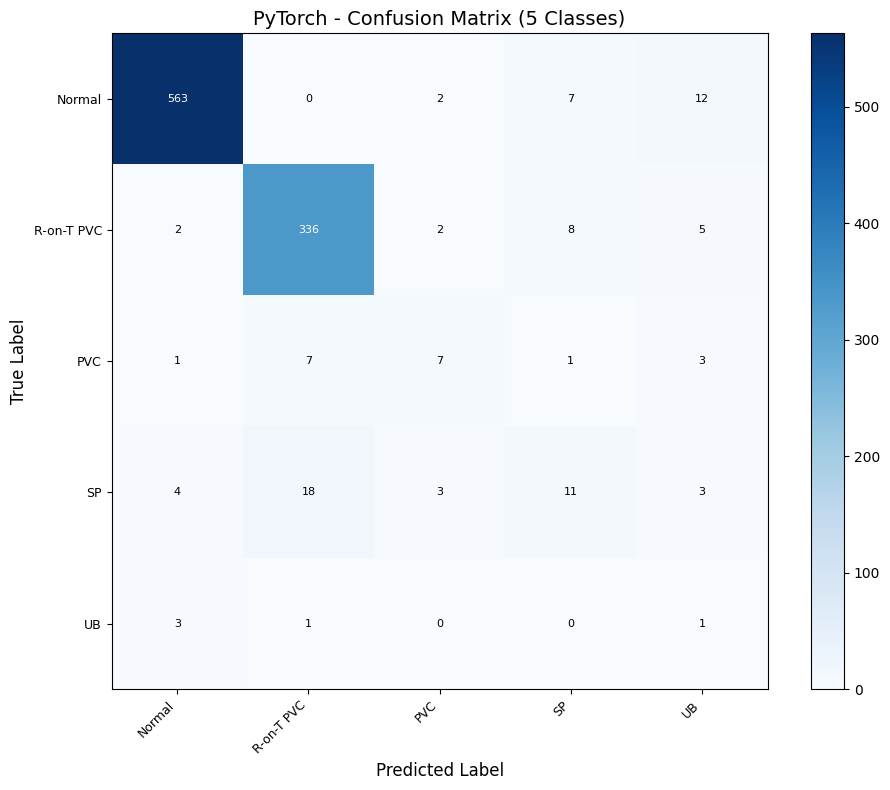

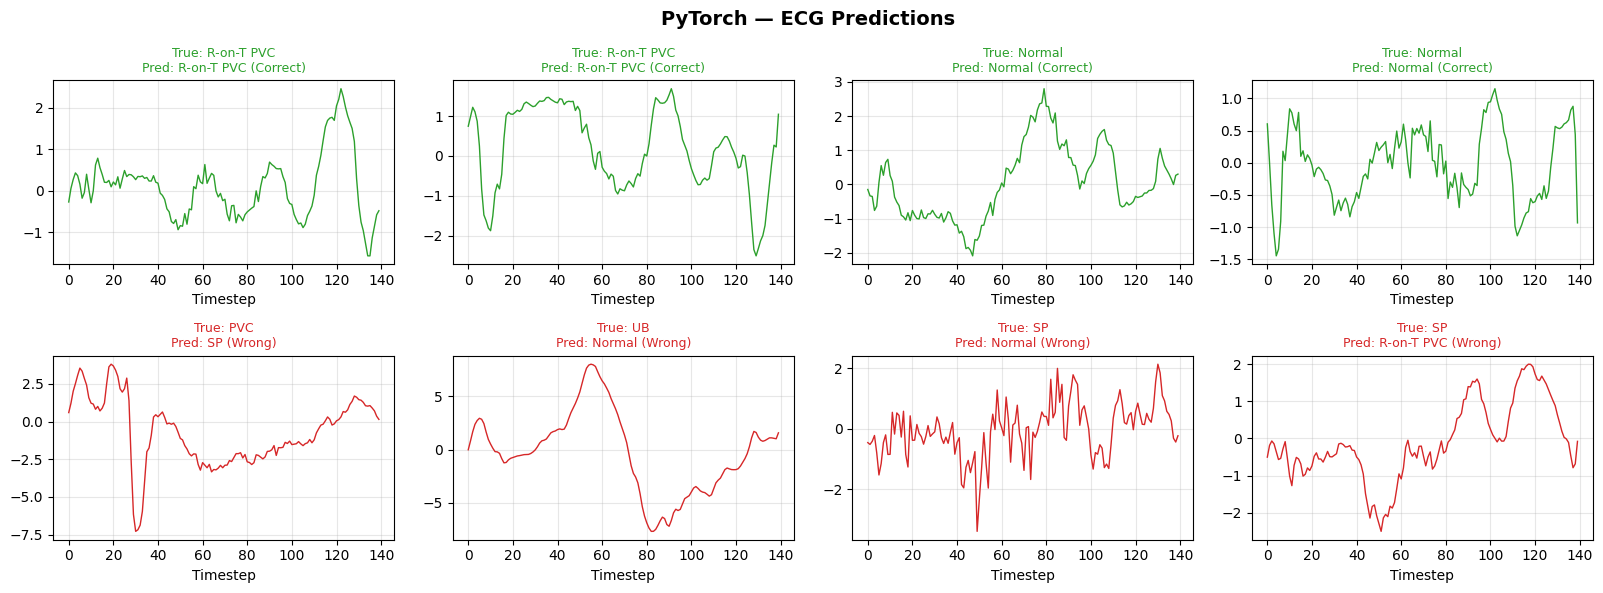

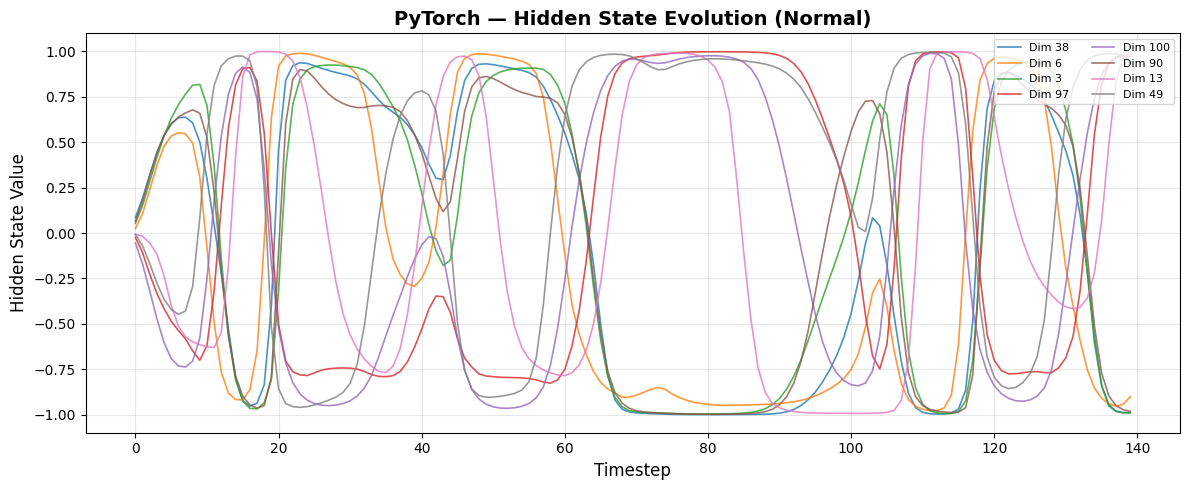

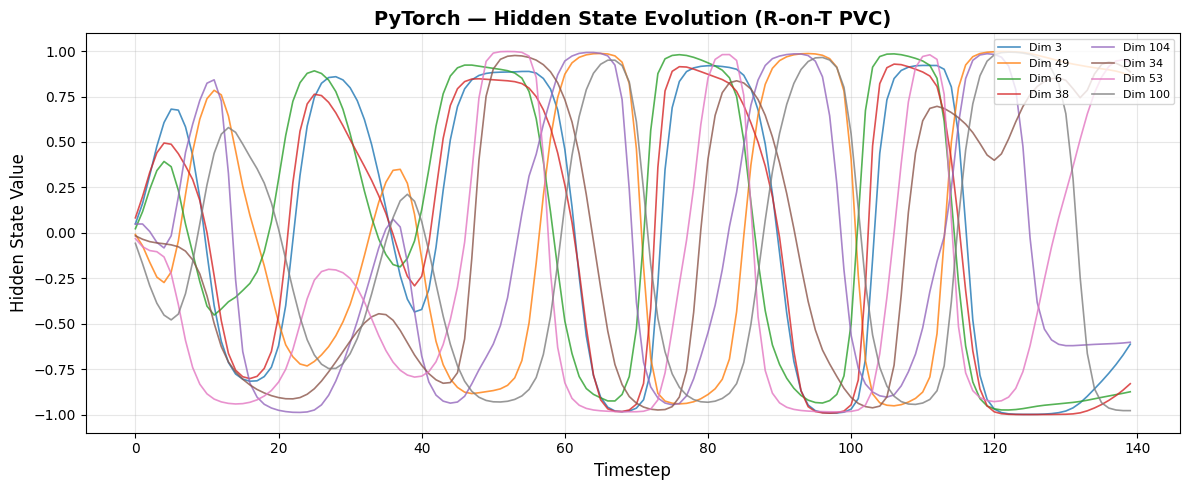

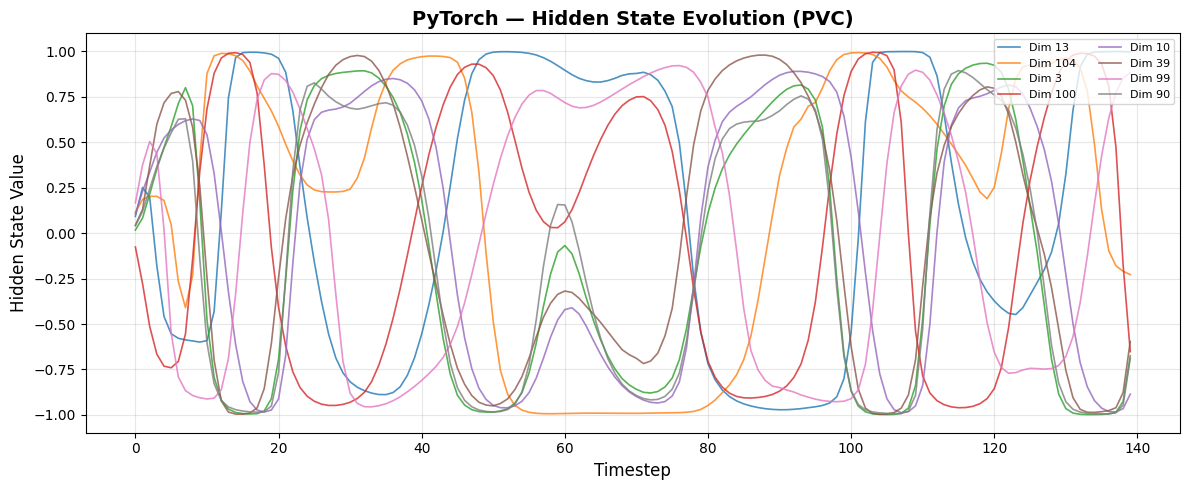

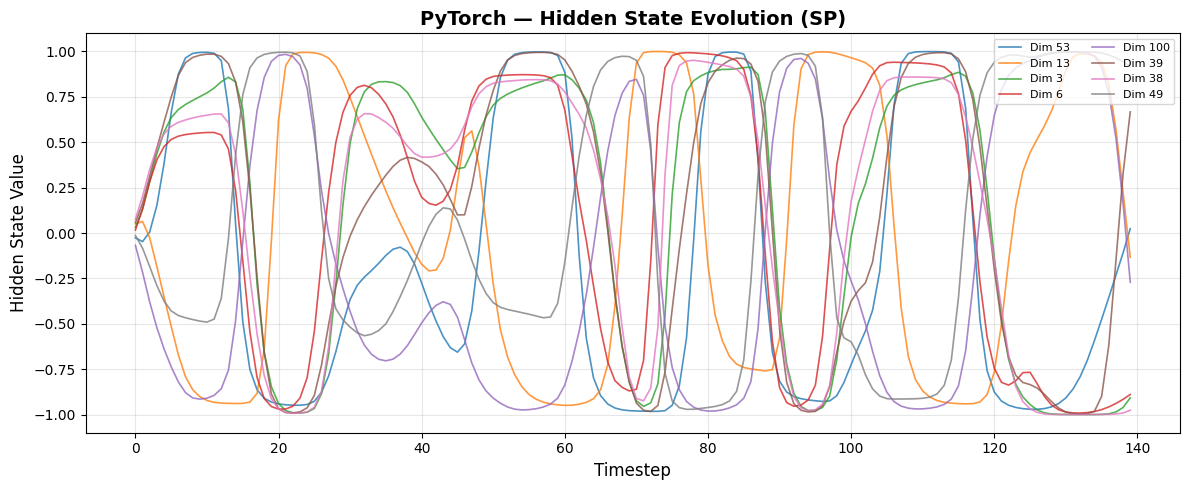

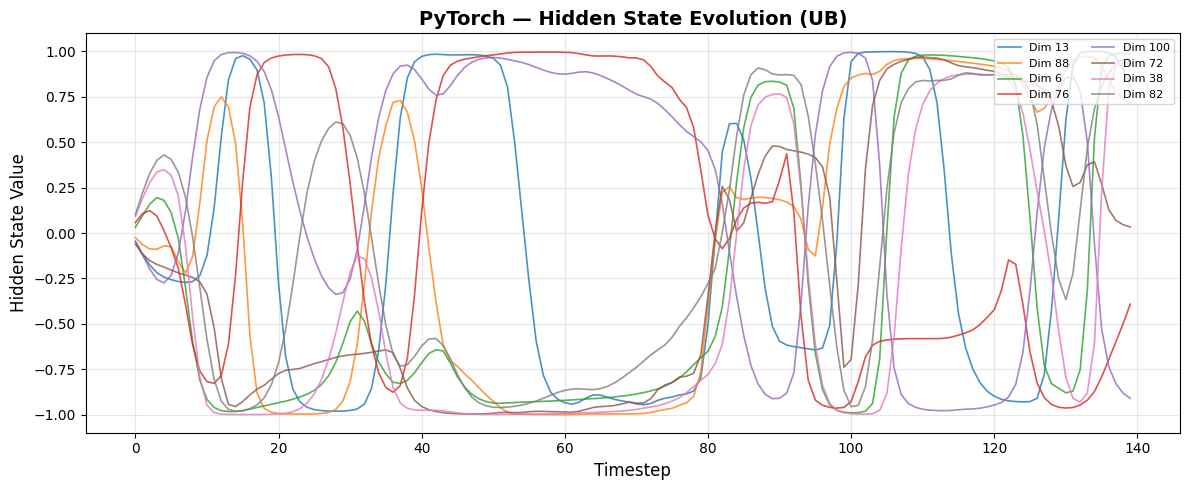


Limitations:
  UB class: only 19 train / 5 test samples — F1 is noisy
  SP class: 39 test samples, often confused with R-on-T PVC
  Macro F1 capped by extreme class imbalance (121.6x ratio)
  Data augmentation + LSTM explored in Model #13


In [6]:
# Step 6: Best Model Full Evaluation
"""
GRU-128 from architecture sweep — best macro F1 (0.5479).
No retrain needed: sweep model already captured with early stopping.
Full eval: confusion matrix, per-class F1, ECG predictions, hidden states.
Limitation: macro F1 capped by extreme imbalance (5 UB test samples).
"""

print("=" * 60)
print("[6/9] Best Model — GRU-128 (Full Evaluation)")
print("=" * 60)

# Use sweep model directly — already trained and evaluated
best_model = sweep_results['GRU-128']['model']
best_preds = sweep_results['GRU-128']['preds']
best_metrics = sweep_results['GRU-128']['metrics']
best_f1 = sweep_results['GRU-128']['macro_f1']
best_per_class = sweep_results['GRU-128']['per_class_f1']
hist_best = sweep_results['GRU-128']['hist']
perf_best = sweep_results['GRU-128']['perf']
n_params_best = sweep_results['GRU-128']['n_params']

print(f"Architecture: GRU(1, 128, 2 layers) -> FC(128, 5)")
print(f"Parameters: {n_params_best:,}")
print(f"Epochs: {hist_best['epochs']} | Best val F1: {hist_best['best_val_f1']:.4f}")
print(f"Training time: {perf_best['time']:.2f}s")
print(f"GPU memory: {perf_best['gpu_memory']:.1f} MB")

print(f"\nTest Results:")
print(f"  Accuracy:  {best_metrics['accuracy']:.4f}")
print(f"  Macro F1:  {best_f1:.4f}")
print(f"\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, best_per_class)):
    n = np.sum(y_test == i)
    print(f"  {name:<15} F1={f1:.4f} (n={n})")

# Confusion Matrix
plot_confusion_matrix_multiclass(y_test, best_preds, CLASS_NAMES,
                                  framework='PyTorch',
                                  save_path='results/confusion_matrix.png')

# ECG Predictions
plot_ecg_predictions(X_test_t.cpu().numpy(), y_test, best_preds, CLASS_NAMES,
                     framework='PyTorch', save_path='results/ecg_predictions.png')

# Hidden State Evolution
best_model.eval()
with torch.no_grad():
    all_output, _ = best_model.gru(X_test_t)  # (1000, 140, 128)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_mask = (y_test == cls_idx)
    if cls_mask.sum() == 0:
        continue
    correct_mask = cls_mask & (best_preds == cls_idx)
    if correct_mask.sum() > 0:
        sample_idx = np.where(correct_mask)[0][0]
    else:
        sample_idx = np.where(cls_mask)[0][0]

    hidden_states = all_output[sample_idx].cpu().numpy()  # (140, 128)
    plot_hidden_state_evolution(
        hidden_states, timesteps=140, class_name=cls_name,
        framework='PyTorch',
        save_path=f'results/hidden_states_{cls_name.replace(" ", "_").lower()}.png'
    )

# Limitations
print(f"\nLimitations:")
print(f"  UB class: only 19 train / 5 test samples — F1 is noisy")
print(f"  SP class: 39 test samples, often confused with R-on-T PVC")
print(f"  Macro F1 capped by extreme class imbalance (121.6x ratio)")
print(f"  Data augmentation + LSTM explored in Model #13")

[7/9] Training Visualization


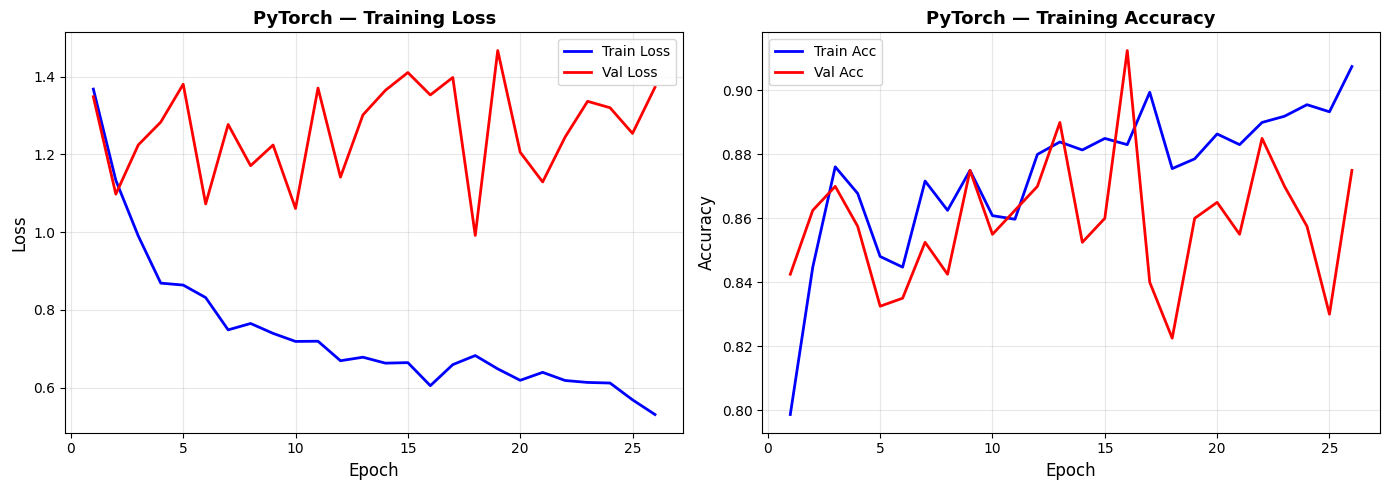

Epochs: 26
Best val F1: 0.5356


In [7]:
# Step 7: Training Visualization
"""
Training curves for GRU-128 from the architecture sweep.
Dual-panel: loss (left) and accuracy (right) over epochs.
"""

print("=" * 60)
print("[7/9] Training Visualization")
print("=" * 60)

plot_training_history(hist_best, framework='PyTorch',
                      save_path='results/training_history.png')

print(f"Epochs: {hist_best['epochs']}")
print(f"Best val F1: {hist_best['best_val_f1']:.4f}")

In [8]:
# Step 8: Performance Benchmarks
"""
Inference timing via track_inference util.
Predict function wraps torch.no_grad + cuda.synchronize for GPU accuracy.
Model size via get_model_size.
"""

print("=" * 60)
print("[8/9] Performance Benchmarks")
print("=" * 60)

best_model.eval()

def predict_fn(X):
    with torch.no_grad():
        preds = best_model(X).argmax(1)
    torch.cuda.synchronize()
    return preds

inference = track_inference(predict_fn, X_test_t, n_runs=100)
model_size = get_model_size(best_model, framework='pytorch')

print(f"Inference ({100} runs x {len(X_test_t)} samples):")
print(f"  Per sample: {inference['per_sample_us']:.2f} µs")
print(f"  Throughput: {inference['samples_per_sec']:,.0f} samples/sec")
print(f"\nModel size: {model_size:,} bytes ({model_size / 1024:.1f} KB)")
print(f"GPU memory (training): {perf_best['gpu_memory']:.1f} MB")

print(f"\n{'='*60}")
print(f"Benchmark Summary")
print(f"{'='*60}")
print(f"  Architecture:     GRU(1, 128, 2 layers) -> FC(128, 5)")
print(f"  Parameters:       {n_params_best:,}")
print(f"  Training time:    {perf_best['time']:.2f}s ({hist_best['epochs']} epochs)")
print(f"  Inference:        {inference['per_sample_us']:.2f} µs/sample")
print(f"  Model size:       {model_size / 1024:.1f} KB")
print(f"  GPU memory:       {perf_best['gpu_memory']:.1f} MB")
print(f"  Accuracy:         {best_metrics['accuracy']:.4f}")
print(f"  Macro F1:         {best_f1:.4f}")

[8/9] Performance Benchmarks
Inference (100 runs x 1000 samples):
  Per sample: 4.82 µs
  Throughput: 207,647 samples/sec

Model size: 600,084 bytes (586.0 KB)
GPU memory (training): 492.9 MB

Benchmark Summary
  Architecture:     GRU(1, 128, 2 layers) -> FC(128, 5)
  Parameters:       150,021
  Training time:    4.17s (26 epochs)
  Inference:        4.82 µs/sample
  Model size:       586.0 KB
  GPU memory:       492.9 MB
  Accuracy:         0.9180
  Macro F1:         0.5479


In [9]:
# Step 9: Save Results
"""
Save model weights, build results dict, save to JSON.
Results follow standard format for cross-framework comparison.
"""

print("=" * 60)
print("[9/9] Save Results")
print("=" * 60)

# Save model weights
torch.save(best_model.state_dict(), 'results/gru_128_best.pth')
print("Model saved: results/gru_128_best.pth")

# Build results dict — pass objects directly, not individual fields
results = build_results_dict(
    framework='PyTorch',
    model_name='RNN',
    test_metrics=best_metrics,
    perf=perf_best,
    inference_stats=inference,
    model_size=model_size,
    rnn_type='GRU',
    hidden_size=128,
    num_layers=2,
    n_params=int(n_params_best),
    epochs=int(hist_best['epochs']),
    best_val_f1=float(hist_best['best_val_f1']),
    gpu_memory_mb=float(perf_best['gpu_memory']),
    class_imbalance_ratio=121.6,
    vanishing_gradient_demo=True,
    architecture='GRU(1, 128, 2 layers) -> FC(128, 5)',
    optimizer='Adam',
    lr=1e-3,
)

save_results(results, 'results')
add_result('rnn', results)
print_comparison('rnn')

[9/9] Save Results
Model saved: results/gru_128_best.pth
    Results saved to: results\metrics.json
    Added 'PyTorch' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\rnn.json
    Frameworks: 2 recorded

CROSS-FRAMEWORK COMPARISON: RNN
Metric                                                     TensorFlow                                PyTorch
------------------------------------------------------------------------------------------------------------
model                                                             RNN                                    RNN
training_time                                                 3.6 min                                 4.17 s
inference_time_per_sample_us                                416.78 µs                                4.82 µs
model_size_bytes                                             394.0 KB                               586.0 KB
peak_memory_mb                                               18.47 MB    

In [10]:
# Step 10: MLflow Tracking + Model Export
"""
Deployment staging — same pattern as DNN and CNN.
Log hyperparams, metrics, model with signature, artifacts.
"""

import mlflow
import mlflow.pytorch
from mlflow.models import infer_signature

print("=" * 60)
print("[10] MLflow Tracking + Model Export")
print("=" * 60)

mlflow.set_experiment("rnn")

with mlflow.start_run(run_name="pytorch-gru-128"):
    # Log hyperparameters
    mlflow.log_params({
        'architecture': 'GRU(1, 128, 2 layers) -> FC(128, 5)',
        'rnn_type': 'GRU',
        'hidden_size': 128,
        'num_layers': 2,
        'n_params': int(n_params_best),
        'optimizer': 'Adam',
        'learning_rate': 1e-3,
        'batch_size': BATCH_SIZE,
        'early_stopping_metric': 'val_macro_f1',
        'early_stopping_patience': 10,
        'random_state': RANDOM_STATE,
        'framework': FRAMEWORK,
        'dataset': 'ECG5000',
        'n_classes': N_CLASSES,
        'seq_len': SEQ_LEN,
        'class_imbalance_ratio': 121.6,
    })

    # Log metrics
    mlflow.log_metrics({
        'accuracy': float(best_metrics['accuracy']),
        'macro_f1': float(best_f1),
        'training_time_s': float(perf_best['time']),
        'inference_us_per_sample': float(inference['per_sample_us']),
        'model_size_bytes': int(model_size),
        'peak_memory_gpu_mb': float(perf_best['gpu_memory']),
        'n_params': int(n_params_best),
        'epochs': int(hist_best['epochs']),
        'best_val_f1': float(hist_best['best_val_f1']),
    })

    # Log model with signature
    best_model_cpu = best_model.cpu()
    best_model_cpu.eval()
    sample_input = X_test_t[:5].cpu()
    with torch.no_grad():
        sample_output = best_model_cpu(sample_input).numpy()
    signature = infer_signature(sample_input.numpy(), sample_output)
    mlflow.pytorch.log_model(best_model_cpu, name="rnn-ecg5000", signature=signature)

    # Log visualizations as artifacts
    mlflow.log_artifacts("results/", artifact_path="visualizations")

    run_id = mlflow.active_run().info.run_id

print(f"\n  Run ID:     {run_id}")
print(f"  Experiment: rnn")

# Export full model locally
torch.save(best_model_cpu, 'results/gru_128_full.pt')
print(f"  State dict: results/gru_128_best.pth (saved in Cell 9)")
print(f"  Full model: results/gru_128_full.pt")
print(f"  Ready for deployment staging")

[10] MLflow Tracking + Model Export


2026/03/28 18:59:45 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/28 18:59:45 INFO mlflow.store.db.utils: Updating database tables
2026/03/28 18:59:45 INFO mlflow.tracking.fluent: Experiment with name 'rnn' does not exist. Creating a new experiment.
2026/03/28 18:59:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/28 18:59:46 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please u


  Run ID:     8c20658bf8a6401fac2dee921807f3fb
  Experiment: rnn
  State dict: results/gru_128_best.pth (saved in Cell 9)
  Full model: results/gru_128_full.pt
  Ready for deployment staging
